# Notebook to compare dataset vs. clade bias

In [1]:
from pathlib import Path
import json

import numpy as np
import pandas as pd

In [2]:
data_folder = Path("../data/processed/train_test_clades")

In [3]:
# concatenate all results.json
results_files = data_folder.glob("**/results.json")
results_list = []
for results_file in results_files:
    with open(results_file) as fid:
        results_list.append(json.load(fid))
results = pd.DataFrame(results_list)

In [4]:
output_file = data_folder / f"{data_folder.stem}.csv"
results.drop(["path"], axis=1).to_csv(output_file, sep=",", index=False)

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

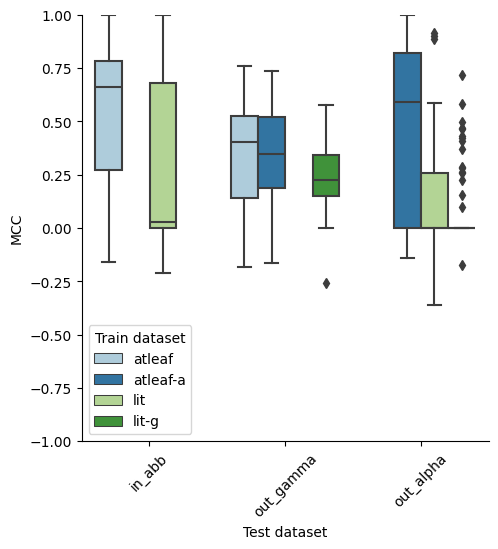

In [14]:
plot_data = results[
    (results.test_set_id.isin(["in_abb", "out_gamma", "out_alpha"])) &
    (results.train_set_id.isin(["atleaf", "lit", "atleaf-a", "lit-g"])) &
    (results.feature_type.isin(["full"]))
    ]
col_order = ["atleaf", "lit"]
order = ["in_abb", "out_gamma", "out_alpha"]
hue_order = ["atleaf", "atleaf-a", "lit", "lit-g"]
palette = sns.color_palette("Paired")
g = sns.catplot(
    data=plot_data,
    x="test_set_id",
    y="matthews_corrcoef",
    hue="train_set_id",
    kind="box",
    hue_order=hue_order,
    order=order,
    palette=palette,
    legend=False
)
plt.xlabel("Test dataset")
plt.ylabel("MCC")
for i, ax in enumerate(g.axes.flat):
    ax.set_ylim(-1, 1)
    # ax.grid(True, axis="x")
    for label in ax.get_xticklabels():
        label.set_rotation(45)
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, labels, title='Train dataset')

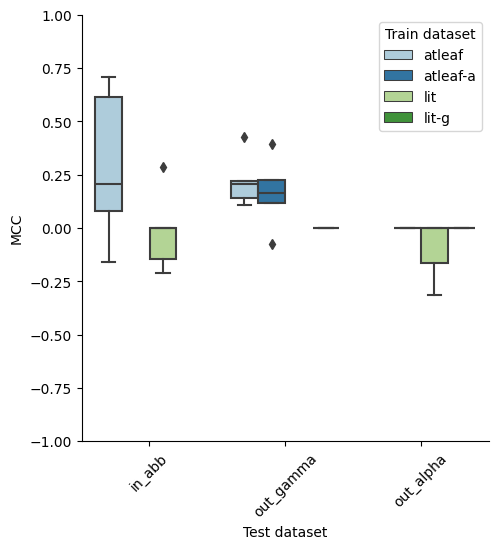

In [20]:
plot_data = results[
    (results.test_set_id.isin(["in_abb", "out_gamma", "out_alpha"])) &
    (results.train_set_id.isin(["atleaf", "lit", "atleaf-a", "lit-g"])) &
    (results.feature_type.isin(["full"])) &
    (results.phenotype_name.isin(["Alanine"]))
    ]
col_order = ["atleaf", "lit"]
order = ["in_abb", "out_gamma", "out_alpha"]
hue_order = ["atleaf", "atleaf-a", "lit", "lit-g"]
palette = sns.color_palette("Paired")
g = sns.catplot(
    data=plot_data,
    x="test_set_id",
    y="matthews_corrcoef",
    hue="train_set_id",
    kind="box",
    hue_order=hue_order,
    order=order,
    palette=palette,
    legend=False
)
plt.xlabel("Test dataset")
plt.ylabel("MCC")
for i, ax in enumerate(g.axes.flat):
    ax.set_ylim(-1, 1)
    # ax.grid(True, axis="x")
    for label in ax.get_xticklabels():
        label.set_rotation(45)
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, labels, title='Train dataset')